# Cosine Similarity With Random Graphs

## 📦 **Package Import**

In [1]:
# python
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import sys
import os
from pathlib import Path
import re

# algorithms4pepprotgraphs framework
sys.path.append('/home/jovyan/work/algorithms4pepprotgraphs')
from algorithms4pepprotgraphs.module.notebook import NotebookApp
from algorithms4pepprotgraphs.util.plotting import boxplot, lineplot

app = NotebookApp('.env.jupyter.AVPDiscover')
paths = app.paths()

[2025-03-23 22:44:17,688] WARNING [data_validator.py:87] Sequences with non-natural amino acids were excluded. See: /home/jovyan/work/output/Test/Test2/Log/Sequences_with_non_natural_amino_acids.csv


## 📊 **Data Analysis**

### **Data**

In [2]:
data = pd.read_csv(app.graph_analysis['similarity_with_random_graphs'])

data["distance_interval"] = data["distance_function"] + " " + data["interval"].astype(str)

statistics = pd.read_csv(
    app.graph_analysis['similarity_with_random_graphs_summary'].with_name(
        app.graph_analysis['similarity_with_random_graphs_summary'].name + "-cosine_similarity.csv"
    )
)

statistics["distance_interval"] = statistics["distance_function"] + " " + statistics["interval"].astype(str)

data[["sequence", "distance_interval", "cosine_similarity"]].head()

,sequence,distance_function,interval,random_graph,cosine_similarity,distance_interval
0,LQQLLFIAFRIGRRRRRRRR,euclidean,"(0, 10)",1,0.688900,"euclidean (0, 10)"
1,LQQLLFIAFRIGRRRRRRRR,euclidean,"(0, 10)",2,0.875269,"euclidean (0, 10)"


### **Distance Intervals**

In [3]:
unique_values = pd.Series(pd.concat([statistics["distance_interval"], statistics["distance_interval"]]).unique()).sort_values()
display(Markdown("\n".join(f"- {val}" for val in unique_values)))

- angular_separation (0, 0.018)
- angular_separation (0, 0.0654)
- angular_separation (0, 0.1799)
- bhattacharyya (0, 1.5158)
- bhattacharyya (0, 2.4304)
- bhattacharyya (0, 3.6452)
- canberra (0, 0.6155)
- canberra (0, 1.0142)
- canberra (0, 1.4712)
- clark (0, 0.4161)
- clark (0, 0.6813)
- clark (0, 0.983)
- euclidean (0, 10)
- euclidean (0, 15)
- euclidean (0, 20)
- lance_williams (0, 0.1789)
- lance_williams (0, 0.3041)
- lance_williams (0, 0.4664)
- soergel (0, 0.3035)
- soergel (0, 0.4664)
- soergel (0, 0.6357)

### **Number of Random Graphs per Distance Interval**

In [4]:
first_sequence = data["sequence"].iloc[0]
df_filtered = data[data["sequence"] == first_sequence]
count = df_filtered.groupby(["distance_function", "interval"])["random_graph"].count()
display(Markdown("\n".join(f"- {idx[0]}, {idx[1]}: {val}" for idx, val in count.items())))

- angular_separation, (0, 0.018): 30
- angular_separation, (0, 0.0654): 30
- angular_separation, (0, 0.1799): 30
- bhattacharyya, (0, 1.5158): 30
- bhattacharyya, (0, 2.4304): 30
- bhattacharyya, (0, 3.6452): 30
- canberra, (0, 0.6155): 30
- canberra, (0, 1.0142): 30
- canberra, (0, 1.4712): 30
- clark, (0, 0.4161): 30
- clark, (0, 0.6813): 30
- clark, (0, 0.983): 30
- euclidean, (0, 10): 30
- euclidean, (0, 15): 30
- euclidean, (0, 20): 30
- lance_williams, (0, 0.1789): 30
- lance_williams, (0, 0.3041): 30
- lance_williams, (0, 0.4664): 30
- soergel, (0, 0.3035): 30
- soergel, (0, 0.4664): 30
- soergel, (0, 0.6357): 30

### **Statistics**

In [5]:
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics.reset_index(drop=True)[columns])

,distance_function,interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis,distance_interval
0,angular_separation,"(0, 0.018)",530130,-1.000000,0.476748,0.266143,0.355087,0.519815,0.659842,1.0,-1.465482,6.570217,"angular_separation (0, 0.018)"
1,angular_separation,"(0, 0.0654)",536338,-1.000000,0.573307,0.247185,0.500344,0.633156,0.721273,1.0,-2.464346,11.251609,"angular_separation (0, 0.0654)"
2,angular_separation,"(0, 0.1799)",536666,-0.972265,0.632265,0.229642,0.604671,0.689651,0.744284,1.0,-3.277980,15.657523,"angular_separation (0, 0.1799)"
3,bhattacharyya,"(0, 1.5158)",536638,-1.000000,0.492961,0.213141,0.380212,0.496552,0.624390,1.0,-1.338560,9.181004,"bhattacharyya (0, 1.5158)"
4,bhattacharyya,"(0, 2.4304)",536664,-0.990305,0.603699,0.164822,0.508984,0.604489,0.711191,1.0,-1.854779,15.797172,"bhattacharyya (0, 2.4304)"
5,bhattacharyya,"(0, 3.6452)",536667,-0.891717,0.663849,0.163145,0.606375,0.678516,0.749510,1.0,-4.357913,33.207037,"bhattacharyya (0, 3.6452)"
6,canberra,"(0, 0.6155)",529829,-1.000000,0.504633,0.252125,0.421403,0.537797,0.649801,1.0,-2.232083,10.911301,"canberra (0, 0.6155)"
7,canberra,"(0, 1.0142)",535680,-1.000000,0.610695,0.188507,0.537401,0.627218,0.716093,1.0,-3.377397,23.756685,"canberra (0, 1.0142)"
8,canberra,"(0, 1.4712)",536609,-1.000000,0.665051,0.150648,0.608518,0.676858,0.743345,1.0,-4.526642,40.152685,"canberra (0, 1.4712)"
9,clark,"(0, 0.4161)",530370,-1.000000,0.507559,0.253392,0.426420,0.543530,0.655107,1.0,-2.177463,10.429433,"clark (0, 0.4161)"


### **Analysis of Graph Similarity Distribution (*per Percentile*)**

#### **25th Percentile**

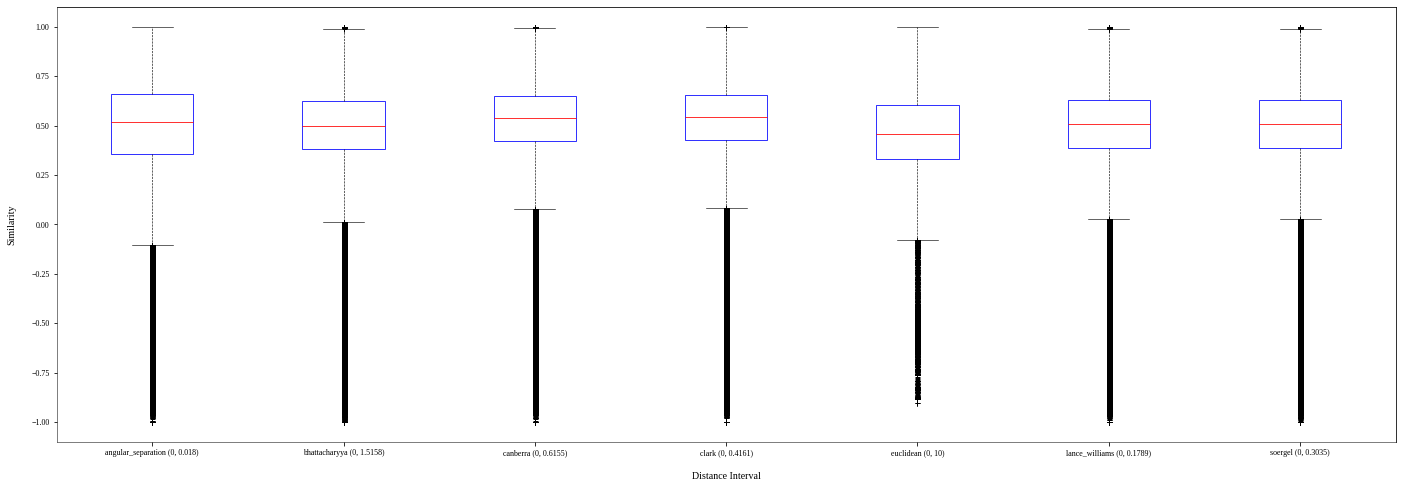

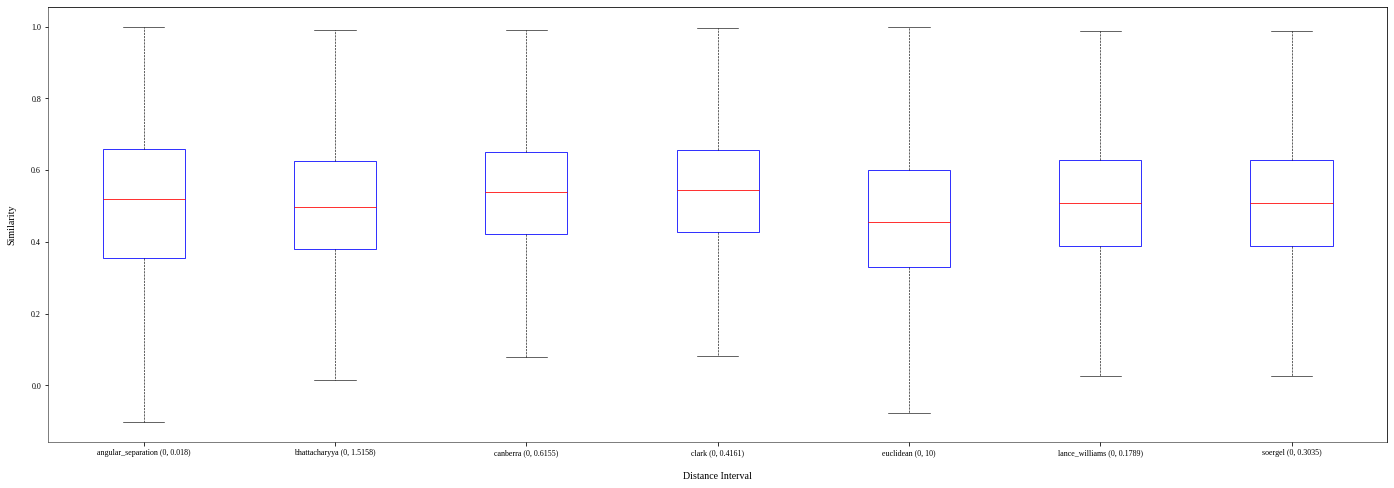

In [7]:
distance_intervals = [
    'euclidean (0, 10)',
    'angular_separation (0, 0.018)',
    'bhattacharyya (0, 1.5158)',
    'canberra (0, 0.6155)',
    'clark (0, 0.4161)',
    'lance_williams (0, 0.1789)',
    'soergel (0, 0.3035)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_rg = data.dropna(subset=['cosine_similarity']).copy()
data_rg = data_rg[data_rg['distance_interval'].astype(str).str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Similarity'
fig_size=(24, 8)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Cosine Similarity with Random Graphs (25th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity with Random Graphs (p25_distance_intervals) -boxplot")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity with Random Graphs (25th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity with Random Graphs (p25_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

#### **50th Percentile**

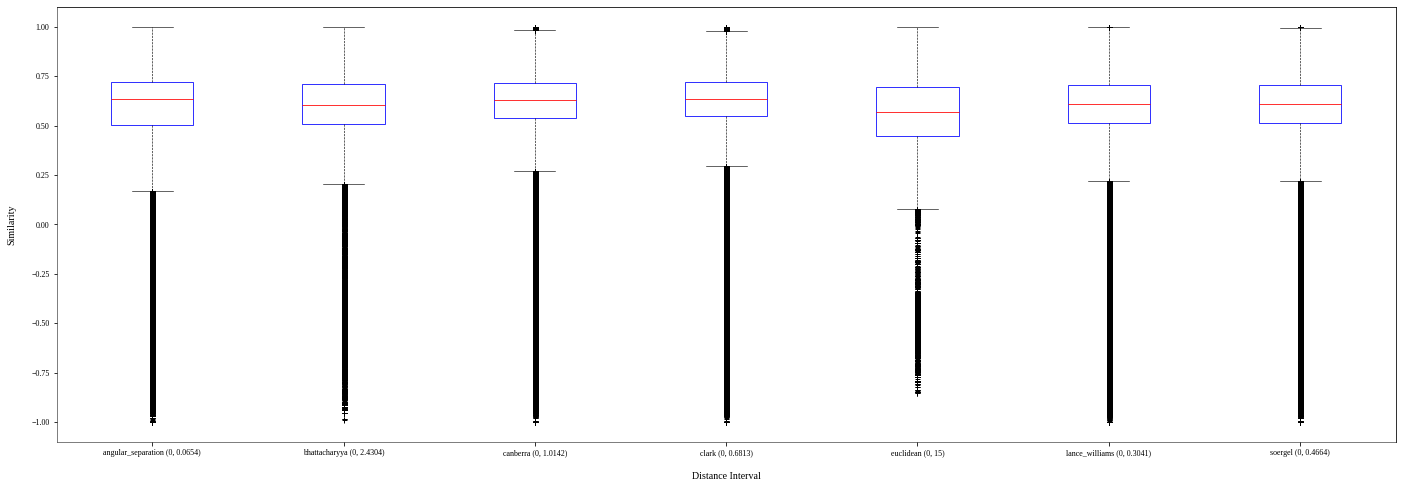

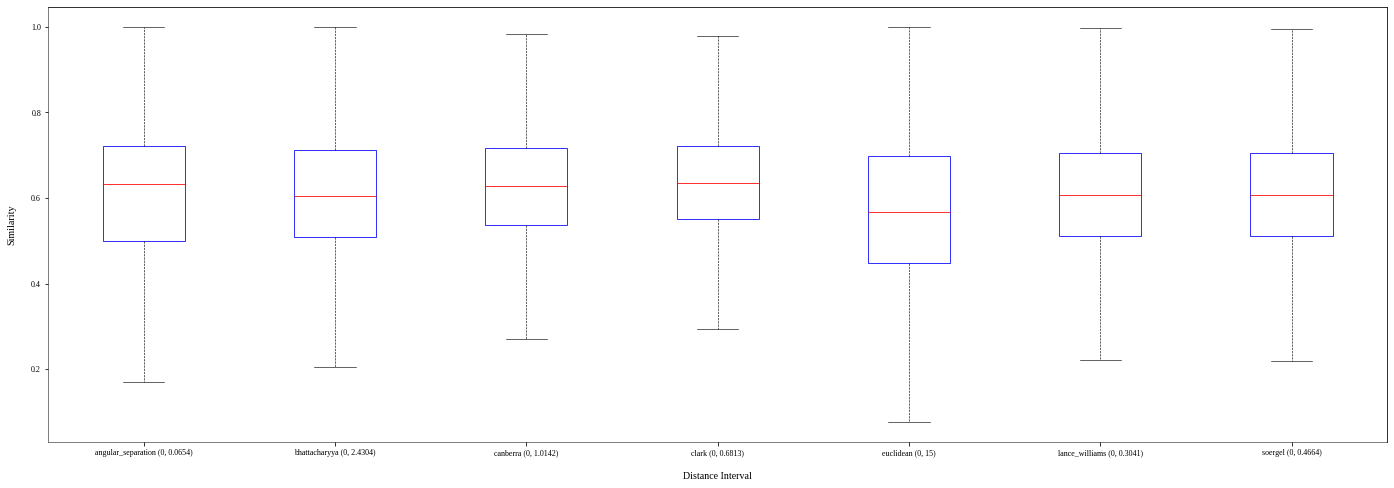

In [8]:
distance_intervals = [
    'euclidean (0, 15)',
    'angular_separation (0, 0.0654)',
    'bhattacharyya (0, 2.4304)',
    'canberra (0, 1.0142)',
    'clark (0, 0.6813)',
    'lance_williams (0, 0.3041)',
    'soergel (0, 0.4664)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_rg = data.dropna(subset=['cosine_similarity']).copy()
data_rg = data_rg[data_rg['distance_interval'].astype(str).str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Similarity'
fig_size=(24, 8)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Cosine Similarity with Random Graphs (50th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity with Random Graphs (p50_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity with Random Graphs (20th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity with Random Graphs (p50_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

#### **75th Percentile**

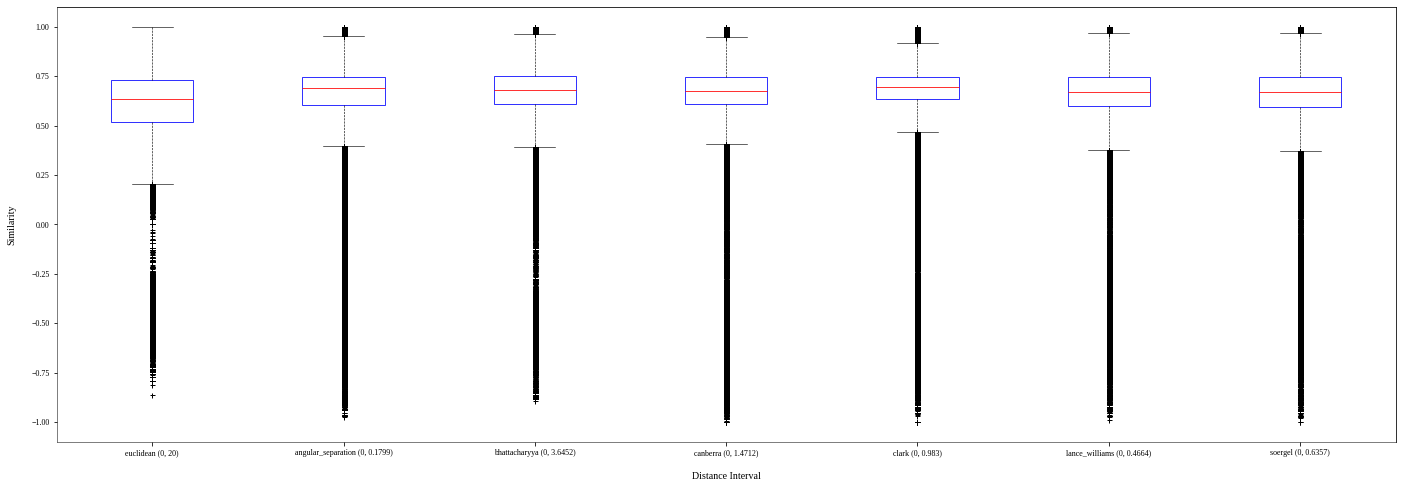

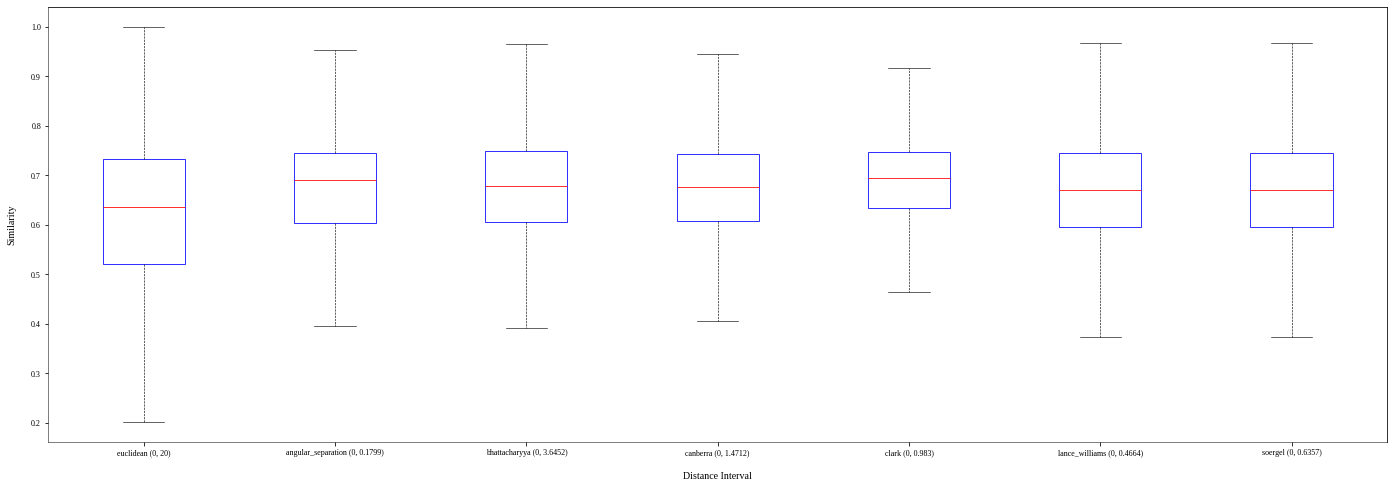

In [11]:
distance_intervals = [
    'euclidean (0, 20)',
    'angular_separation (0, 0.1799)',
    'bhattacharyya (0, 3.6452)',
    'canberra (0, 1.4712)',
    'clark (0, 0.983)',
    'lance_williams (0, 0.4664)',
    'soergel (0, 0.6357)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_rg = data.dropna(subset=['cosine_similarity']).copy()
data_rg = data_rg[data_rg['distance_interval'].astype(str).str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Similarity'
fig_size=(24, 8)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Cosine Similarity with Random Graphs (75th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity with Random Graphs (p75_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, categories=distance_intervals)
plt.show()

display(Markdown("<br>*Cosine Similarity with Random Graphs (75th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity with Random Graphs (p75_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False, categories=distance_intervals)
plt.show()